# RAG with Persistent Memory Using LangGraph

In real-world applications, Retrieval-Augmented Generation (RAG) cannot operate in isolation. Users ask multi-turn questions, reference earlier answers with pronouns (*"Can you explain the second point?"* or *"How does that compare?"*), and expect the assistant to remember previous context.

This notebook implements **RAG with Persistent State & Memory** using **LangGraph Checkpointing** (`MemorySaver`) and **MessagesState**.

## Workflow Architecture

<div align="center">
  <img src="workflow_architecture.png" alt="RAG with Persistent Memory Architecture Diagram" width="550" />
</div>

<details>
<summary><b>Click to expand Colorful Mermaid Source Code</b></summary>

```mermaid
flowchart TD
    subgraph Client["Client Interaction"]
        User(["1. User Message<br/>(Question or Follow-up)"]):::startNode
        ThreadConfig[("Thread Config<br/>thread_id: 'abc123'")]:::threadNode
    end

    subgraph MemoryLayer["Persistent Memory and State Layer"]
        Checkpoint[("LangGraph Checkpointer<br/><b>MemorySaver</b><br/>(Retains Thread Checkpoints)")]:::memNode
        MessagesStateNode["MessagesState<br/>(Appends Conversation History)"]:::stateNode
    end

    subgraph ExecutionGraph["StateGraph Execution Runtime"]
        QueryOrRespond["2. query_or_respond Node<br/><b>Groq LLM + Tool Binding</b><br/>(Decides to search or respond)"]:::llmNode
        Decision{"tools_condition<br/>Tool Call Generated?"}:::decideNode
        ToolExec["3. tools Node (ToolNode)<br/><b>FAISS Vector Store</b><br/>(HuggingFace MiniLM Embeddings)"]:::toolNode
        GenerateNode["4. generate Node<br/><b>Groq LLM Synthesis</b><br/>(Context + Multi-Turn History)"]:::genNode
    end

    Out(["5. AI Response<br/>(Answer Returned and State Checkpointed)"]):::endNode

    User --> QueryOrRespond
    ThreadConfig -.-> Checkpoint
    Checkpoint <--> MessagesStateNode
    MessagesStateNode <--> QueryOrRespond
    QueryOrRespond --> Decision
    Decision -->|Tool Call: 'retrieve'| ToolExec
    Decision -->|No Tool Call: Direct Reply| Out
    ToolExec --> GenerateNode
    GenerateNode --> MessagesStateNode
    GenerateNode --> Out

    classDef startNode fill:#E8F5E9,stroke:#2E7D32,stroke-width:2px,color:#1B5E20;
    classDef threadNode fill:#E0F7FA,stroke:#00838F,stroke-width:2px,color:#004D40;
    classDef memNode fill:#FFF8E1,stroke:#FFA000,stroke-width:2px,color:#E65100;
    classDef stateNode fill:#EDE7F6,stroke:#5E35B1,stroke-width:2px,color:#311B92;
    classDef llmNode fill:#E3F2FD,stroke:#1565C0,stroke-width:2px,color:#0D47A1;
    classDef decideNode fill:#FCE4EC,stroke:#C2185B,stroke-width:2px,color:#880E4F;
    classDef toolNode fill:#FFF3E0,stroke:#EF6C00,stroke-width:2px,color:#BF360C;
    classDef genNode fill:#F3E5F5,stroke:#7B1FA2,stroke-width:2px,color:#4A148C;
    classDef endNode fill:#FFEBEE,stroke:#D32F2F,stroke-width:2px,color:#B71C1C;
```
</details>

### Key Architectural Features
- **Thread-Scoped Memory**: State checkpoints are keyed by `thread_id`, enabling isolated, independent multi-user sessions.
- **Tool-Aware Decisions**: The LLM autonomously determines whether external knowledge retrieval is necessary or if it can answer conversational queries directly.
- **End-to-End Context Grounding**: The generation step synthesizes answers combining the retrieved context chunks and the multi-turn dialogue history.
- **ReAct Agent Integration**: Demonstrates both custom LangGraph StateGraph orchestration and prebuilt `create_react_agent` with checkpointers.


## Step 0: Environment Setup

Load environment variables from `.env` and initialize the **Groq LLM** (`openai/gpt-oss-120b`).

**Required Python Packages:**
```bash
pip install langchain langchain-community langchain-groq langchain-huggingface \
            faiss-cpu langgraph python-dotenv beautifulsoup4 sentence-transformers
```


In [1]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model

# Load environment variables from .env
load_dotenv()
os.environ['USER_AGENT'] = os.getenv('USER_AGENT', 'RAGMemory/1.0')
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

# Initialize Groq Chat Model
llm = init_chat_model('groq:openai/gpt-oss-120b')
print('Environment loaded and Groq LLM initialized successfully.')
llm


Environment loaded and Groq LLM initialized successfully.


ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002C04BA91D30>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002C04BA927B0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

## Step 1: Initialize Local HuggingFace Embeddings

We use **`sentence-transformers/all-MiniLM-L6-v2`** via `HuggingFaceEmbeddings`:
- **384-dimensional dense semantic vectors**
- Fast, accurate, and runs **completely locally** without third-party API dependencies or costs


In [2]:
from langchain_huggingface import HuggingFaceEmbeddings

# Initialize HuggingFace local embeddings
embeddings = HuggingFaceEmbeddings(
    model_name='sentence-transformers/all-MiniLM-L6-v2'
)
print('HuggingFace embeddings model loaded successfully.')
embeddings


c:\RAG\Code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11724.20it/s]


HuggingFace embeddings model loaded successfully.


HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

## Step 2: Document Ingestion and Chunking

We ingest Lilian Weng's article on **LLM-Powered Autonomous Agents** using `WebBaseLoader` with `bs4.SoupStrainer` to focus on the core article content, followed by `RecursiveCharacterTextSplitter`.


In [3]:
import bs4
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Load and parse the blog post
loader = WebBaseLoader(
    web_paths=('https://lilianweng.github.io/posts/2023-06-23-agent/',),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=('post-content', 'post-title', 'post-header')
        )
    ),
)
docs = loader.load()

# Split text into semantically cohesive chunks
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)
all_splits = text_splitter.split_documents(docs)

print(f'Loaded {len(docs)} document and created {len(all_splits)} chunks.')


C:\Users\itsar\AppData\Local\Temp\ipykernel_46236\2504442199.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader


Loaded 1 document and created 63 chunks.


## Step 3: Build the FAISS Vector Store

We embed the document chunks into an in-memory **FAISS** vector store to enable fast similarity search.


In [4]:
from langchain_community.vectorstores import FAISS

# Build the FAISS vector store
vector_store = FAISS.from_documents(
    documents=all_splits,
    embedding=embeddings
)

print(f'FAISS vector store created with {vector_store.index.ntotal} vectors.')


FAISS vector store created with 63 vectors.


## Step 4: Define the Retrieval Tool

We wrap FAISS similarity search as a LangChain `@tool` so the LLM can autonomously invoke it when information retrieval is required.


In [ ]:
from langchain_core.tools import tool

@tool
def retrieve(query: str) -> str:
    """Retrieve information related to the query from the internal knowledge base."""
    retrieved_docs = vector_store.similarity_search(query, k=2)
    serialized = '\n\n'.join(f'Source: {doc.metadata}\nContent: {doc.page_content}' for doc in retrieved_docs)
    return serialized

# Sanity test
test_retrieval = retrieve.invoke({'query': 'Task Decomposition'})
print('Retrieval Tool Sanity Test Output (First 300 chars):')
print(test_retrieval[:300] + '...')


Retrieval Tool Sanity Test Output (First 300 chars):
Source: {'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}
Content: Task decomposition can be done (1) by LLM with simple prompting like "Steps for XYZ.\n1.", "What are the subgoals for achieving XYZ?", (2) by using task-specific instructions; e.g. "Write a story outline." for writin...


## Step 5: Define LangGraph Workflow Nodes

We define the three core nodes that govern the RAG cycle:
1. **`query_or_respond`**: The LLM is bound to the `retrieve` tool. It inspects the dialogue history and decides whether to output a tool call (to search FAISS) or answer directly.
2. **`tools`**: `ToolNode([retrieve])` executes the tool call and returns the retrieved documents as a `ToolMessage`.
3. **`generate`**: Synthesizes a grounded, concise answer using both retrieved tool results and the ongoing conversation history.


In [ ]:
from langchain_core.messages import SystemMessage
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode

# Node 1: Decide whether to call the retrieval tool or reply directly
def query_or_respond(state: MessagesState):
    """Generate tool call for retrieval or respond directly."""
    llm_with_tools = llm.bind_tools([retrieve])
    response = llm_with_tools.invoke(state['messages'])
    return {'messages': [response]}

# Node 2: Tool execution node
tools = ToolNode([retrieve])

# Node 3: Grounded generation node
def generate(state: MessagesState):
    """Generate grounded answer using retrieved context and conversation history."""
    # Extract tool messages from recent steps
    recent_tool_messages = []
    for message in reversed(state['messages']):
        if message.type == 'tool':
            recent_tool_messages.append(message)
        else:
            break
    tool_messages = recent_tool_messages[::-1]

    # Format retrieved context into system prompt
    docs_content = '\n\n'.join(doc.content for doc in tool_messages)
    system_message_content = (
        'You are an assistant for question-answering tasks. '
        'Use the following pieces of retrieved context to answer '
        'the question. If you do not know the answer, say that you '
        'do not know. Use three sentences maximum and keep the '
        'answer concise.\n\n'
        f'{docs_content}'
    )

    # Filter out redundant intermediate tool calls from LLM input
    conversation_messages = [message for message in state['messages'] if message.type in ('human', 'system') or (message.type == 'ai' and not message.tool_calls)]
    prompt = [SystemMessage(content=system_message_content)] + conversation_messages

    response = llm.invoke(prompt)
    return {'messages': [response]}

print('LangGraph nodes defined successfully.')


LangGraph nodes defined successfully.


## Step 6: Assemble and Compile the Graph with Persistent Memory

We construct the `StateGraph(MessagesState)`, wire the conditional edge using `tools_condition`, and attach a **`MemorySaver` checkpointer**.

- **`MemorySaver`**: Stores conversation checkpoints in-memory keyed by `thread_id`.
- **`tools_condition`**: Automatically routes to `'tools'` if the LLM produced a tool call, or `END` if it produced a direct conversational response.


LangGraph RAG workflow with persistent memory compiled successfully!



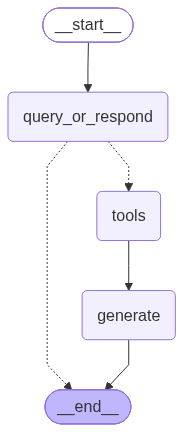

In [12]:
from langgraph.graph import END, StateGraph
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display

# Initialize graph builder with MessagesState schema
graph_builder = StateGraph(MessagesState)

# Add nodes
graph_builder.add_node('query_or_respond', query_or_respond)
graph_builder.add_node('tools', tools)
graph_builder.add_node('generate', generate)

# Set entry point and routing edges
graph_builder.set_entry_point('query_or_respond')
graph_builder.add_conditional_edges(
    'query_or_respond',
    tools_condition,
    {END: END, 'tools': 'tools'},
)
graph_builder.add_edge('tools', 'generate')
graph_builder.add_edge('generate', END)

# Attach in-memory checkpointer
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

print('LangGraph RAG workflow with persistent memory compiled successfully!\n')
graph


## Step 7: Multi-Turn Conversation Demonstration (Thread `abc123`)

We now execute a multi-turn conversation on thread `abc123` to prove persistent memory retention:
1. **Turn 1 (Greeting)**: `"Hello"` $\rightarrow$ No tool call needed $\rightarrow$ Direct friendly response.
2. **Turn 2 (Knowledge Query)**: `"What is Task Decomposition?"` $\rightarrow$ Tool call triggered $\rightarrow$ Retrieves from FAISS $\rightarrow$ Generates grounded explanation.
3. **Turn 3 (Pronoun Follow-up)**: `"Can you look up some common ways of doing it?"` $\rightarrow$ **Memory in action!** The model resolves *"doing it"* as Task Decomposition, retrieves sub-task decomposition techniques, and responds in context.


In [8]:
# Configure thread ID for persistent session
config = {'configurable': {'thread_id': 'abc123'}}

# ------------------------------------------------------------------
# Turn 1: Conversational Greeting
# ------------------------------------------------------------------
print('=' * 75)
print("TURN 1: USER: 'Hello'")
print('=' * 75)
input_message = 'Hello'
for step in graph.stream(
    {'messages': [{'role': 'user', 'content': input_message}]},
    stream_mode='values',
    config=config,
):
    pass
step['messages'][-1].pretty_print()

# ------------------------------------------------------------------
# Turn 2: Specific Knowledge Retrieval
# ------------------------------------------------------------------
print('\n' + '=' * 75)
print("TURN 2: USER: 'What is Task Decomposition?'")
print('=' * 75)
input_message = 'What is Task Decomposition?'
for step in graph.stream(
    {'messages': [{'role': 'user', 'content': input_message}]},
    stream_mode='values',
    config=config,
):
    pass
step['messages'][-1].pretty_print()

# ------------------------------------------------------------------
# Turn 3: Contextual Pronoun Follow-up
# ------------------------------------------------------------------
print('\n' + '=' * 75)
print("TURN 3: USER: 'Can you look up some common ways of doing it?'")
print('=' * 75)
input_message = 'Can you look up some common ways of doing it?'
for step in graph.stream(
    {'messages': [{'role': 'user', 'content': input_message}]},
    stream_mode='values',
    config=config,
):
    pass
step['messages'][-1].pretty_print()


TURN 1: USER: 'Hello'
================================== Ai Message ==================================

Hello! How can I help you today?

TURN 2: USER: 'What is Task Decomposition?'
================================== Ai Message ==================================

**Task decomposition** is the practice of breaking a larger, often complex, activity or goal into smaller, more manageable sub‑tasks or components. By dividing a big problem into bite‑size pieces, you make it easier to understand, plan, assign, track, and execute the work.  

Below is a concise overview of what task decomposition entails, why it’s useful, where it’s applied, and how you can do it effectively.

---

## 1. Core Definition
- **Task decomposition** = *splitting a high‑level task into a hierarchy of lower‑level tasks* (often called subtasks, work items, or steps) until each piece is small enough to be clearly defined, estimated, and acted upon.

---

## 2. Why It Matters
| Benefit | Explanation |
|--------|--------

## Step 8: Inspecting Conversation History in Persistent Checkpoint

We inspect the full state preserved inside the `MemorySaver` checkpointer for thread `abc123` via `graph.get_state(config)`.


In [9]:
# Retrieve all checkpointed messages for thread 'abc123'
chat_history = graph.get_state(config).values['messages']
print(f'Total messages stored in checkpoint for thread abc123: {len(chat_history)}\n')

for i, message in enumerate(chat_history):
    print(f'--- Message {i+1} [{message.type.upper()}] ---')
    message.pretty_print()


Total messages stored in checkpoint for thread abc123: 8

--- Message 1 [HUMAN] ---
================================ Human Message =================================

Hello
--- Message 2 [AI] ---
================================== Ai Message ==================================

Hello! How can I help you today?
--- Message 3 [HUMAN] ---
================================ Human Message =================================

What is Task Decomposition?
--- Message 4 [AI] ---
================================== Ai Message ==================================

**Task decomposition** is the practice of breaking a larger, often complex, activity or goal into smaller, more manageable sub‑tasks or components. By dividing a big problem into bite‑size pieces, you make it easier to understand, plan, assign, track, and execute the work.  

Below is a concise overview of what task decomposition entails, why it’s useful, where it’s applied, and how you can do it effectively.

---

## 1. Core Definition
- **Task

## Step 9: ReAct Agent Architecture with Persistent Memory

As an alternative to building a custom StateGraph from scratch, LangGraph provides prebuilt **ReAct agents** (`create_react_agent`) that natively support checkpointers for multi-turn conversational tool execution.


C:\Users\itsar\AppData\Local\Temp\ipykernel_46236\168432602.py:5: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_executor = create_react_agent(llm, [retrieve], checkpointer=react_memory)


ReAct Agent compiled with persistent memory successfully!



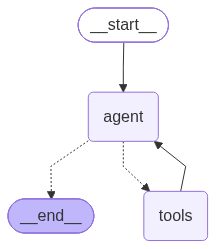

In [13]:
from langgraph.prebuilt import create_react_agent

# Initialize fresh memory checkpointer for the ReAct agent
react_memory = MemorySaver()
agent_executor = create_react_agent(llm, [retrieve], checkpointer=react_memory)

print('ReAct Agent compiled with persistent memory successfully!\n')
agent_executor


## Step 10: Run the ReAct Agent on Thread `def234`

We test the ReAct Agent on a multi-part prompt requiring planning, tool invocation, and memory tracking:
> *"What is the standard method for Task Decomposition? Once you get the answer, look up common extensions of that method."*


In [11]:
# Configure separate thread for ReAct agent session
react_config = {'configurable': {'thread_id': 'def234'}}

react_prompt = (
    'What is the standard method for Task Decomposition?\n\n'
    'Once you get the answer, look up common extensions of that method.'
)

print('=' * 75)
print('EXECUTING REACT AGENT WITH PERSISTENT MEMORY')
print('=' * 75)

for event in agent_executor.stream(
    {'messages': [{'role': 'user', 'content': react_prompt}]},
    stream_mode='values',
    config=react_config,
):
    pass

event['messages'][-1].pretty_print()


EXECUTING REACT AGENT WITH PERSISTENT MEMORY
================================== Ai Message ==================================

**Standard method for Task Decomposition**

The de‑facto “standard” technique used today to break a complex problem into smaller, manageable pieces is **Chain‑of‑Thought (CoT) prompting**.  
In a CoT prompt the model is asked to *“think step‑by‑step”* (or to list the sub‑steps of a task).  By generating an explicit reasoning trace, the model can turn a single, hard‑to‑solve query into a sequence of simpler sub‑problems that are solved sequentially.  This simple prompting trick has become the baseline for most recent work on LLM‑based reasoning and planning 【source†1】.

---

### Common extensions of Chain‑of‑Thought

Researchers have built on the basic CoT idea in a number of directions.  The most frequently cited extensions are:

| Extension | Core idea (how it builds on CoT) | Typical use‑cases / benefits |
|-----------|----------------------------------|-----

## Summary

| Component | Technology | Role |
|---|---|---|
| **Embeddings** | HuggingFace `sentence-transformers/all-MiniLM-L6-v2` | Fast, local 384-dimensional dense semantic vectors |
| **Vector Store** | FAISS | In-memory similarity search over ingested knowledge |
| **LLM Engine** | Groq `openai/gpt-oss-120b` (`init_chat_model`) | Fast high-throughput reasoning, tool calling, and QA synthesis |
| **State Management** | LangGraph `MessagesState` | Preserves and appends conversation messages and tool outputs |
| **Persistence Layer** | LangGraph `MemorySaver` | Thread-scoped checkpoint storage across multi-turn sessions |
| **Tool Calling** | LangChain `@tool` & `ToolNode` | Autonomously retrieves from vector store when needed |
| **Agent Architecture** | Custom StateGraph & `create_react_agent` | Flexible dual implementation: explicit state control vs autonomous ReAct |

### Architectural Comparison: Stateless RAG vs Naive Chat RAG vs LangGraph Checkpointed RAG

| Feature | Stateless RAG | Naive Chat RAG (In-Memory List) | LangGraph Checkpointed RAG |
|---|---|---|---|
| **Multi-turn Memory** | ❌ None (each query isolated) | ⚠️ Python list in app memory | ✅ **Thread-scoped checkpointed state** |
| **Session Isolation** | ❌ None | ⚠️ Vulnerable to cross-user leakage | ✅ **Isolated by `thread_id`** |
| **Tool Autonomy** | ❌ Hardcoded retrieval | ⚠️ Rigid sequential chains | ✅ **Dynamic via `tools_condition`** |
| **State Inspection** | ❌ No state to inspect | ⚠️ Manual logging required | ✅ **`get_state(config)` with full history** |
| **Resumability** | ❌ Cannot resume | ❌ Lost on app restart | ✅ **Can pause, rewind, or persist to DB** |
